# 📊 Desafio TOTVS - Cientista de Dados III (People Analytics)

## Notebook 01: Análise Exploratória de Dados (EDA) e Experimentação de Modelos

Este notebook cobre o requisito central do desafio: **Análise Exploratória**. Focaremos em entender o perfil dos colaboradores, as principais classes que impulsionam a evasão (Churn) e testar qual algoritmo base possui a melhor curva ROC-AUC.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Exibir gráficos offline
%matplotlib inline
sns.set_theme(style="whitegrid")

### 1. Carga Inicial do Dataset IBM HR

In [2]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(f"Tamanho do dataset: {df.shape}")
df.head()

Tamanho do dataset: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### 2. Verificação de Integridade Física

In [3]:
# Verificando valores nulos (Não há nulos neste dataset oficial)
print("Valores missing:", df.isna().sum().sum())

# Tipos de Colunas
df.info()

Valores missing: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLe

### 3. Distribuição da Variável Target (Desbalanceamento)

In [4]:
fig = px.pie(df, names="Attrition", title="Proporção de Atrito (Variável Alvo)", hole=0.4, color_discrete_sequence=['#2ecc71', '#ef4444'])
fig.show()

v_count = df['Attrition'].value_counts(normalize=True) * 100
print(f"Permanecem (No): {v_count['No']:.2f}% | Saíram (Yes): {v_count['Yes']:.2f}%")
# Conclusão do Gráfico: O TARGET requer reamostragem ou pesos adaptativos (Técnica: SMOTE ou scale_pos_weight).

Permanecem (No): 83.88% | Saíram (Yes): 16.12%


### 4. Análise Demográfica Correlacional e Perfis de Risco

In [5]:
fig_age = px.histogram(df, x="Age", color="Attrition", barmode="overlay", 
                       title="Idade X Taxa de Saída", color_discrete_sequence=['#3498db', '#e74c3c'])
fig_age.show()
# Insight: Percebemos que profissionais mais jovens (< 32 anos) têm evasão muito mais agressiva.

In [6]:
attrition_rate_dept = df.groupby('Department')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
attrition_rate_dept.columns = ['Department', 'Attrition Rate (%)']

fig_dept = px.bar(attrition_rate_dept, x='Department', y='Attrition Rate (%)', color='Department',
                  title="Taxa Percentual de Saída por Departamento")
fig_dept.show()
# Insight: Setor de Sales sofre mais evasão relativa (quase 21%) que R&D.

C:\Users\david\AppData\Local\Temp\ipykernel_44772\3383058426.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




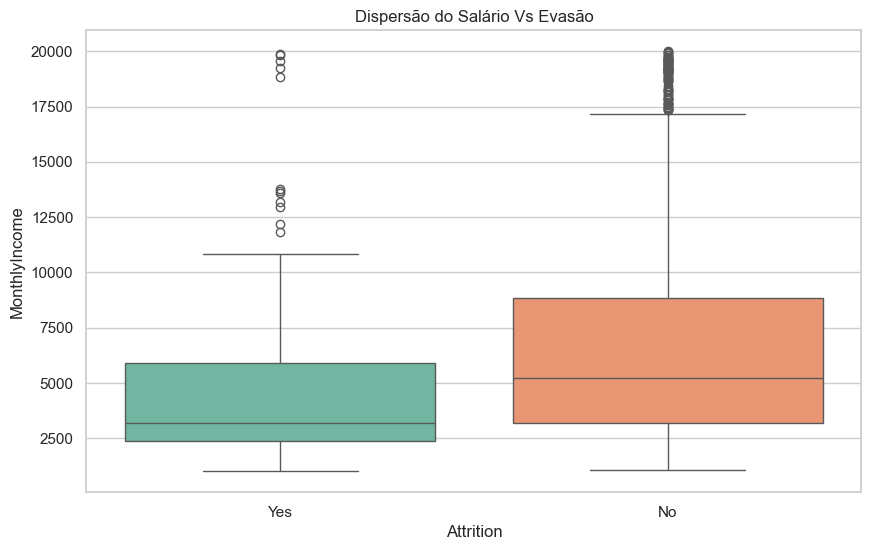

In [7]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette="Set2")
plt.title('Dispersão do Salário Vs Evasão')
plt.show()
# Insight: Quem churna ('Yes') detém salários marcadamente menores.

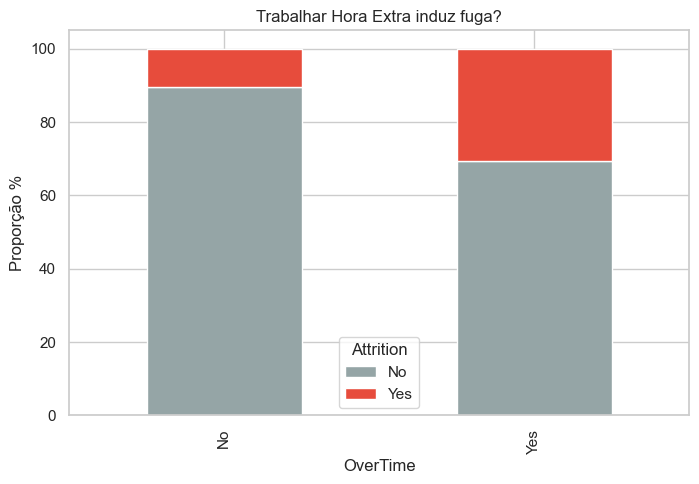

In [8]:
# Analisando Horas Extras (Impacto de Esgotamento/Burnout)
cross = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
cross.plot(kind='bar', stacked=True, color=['#95a5a6','#e74c3c'], figsize=(8,5))
plt.title('Trabalhar Hora Extra induz fuga?')
plt.ylabel('Proporção %')
plt.show()
# Insight Absoluto: Empregados submetidos a Over Time saem DUAS vezes mais do que os que não fazem.

### 5. Preparação dos Dados (Pipelines Isolados)
Abaixo consolidamos uma experimentação leve. Os arquivos de Produção (API) utilizarão o diretório `src/ml` contruído neste projeto de forma mais robusta.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# Drop colunas redundantes
df_ml = df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'])

# Encodings rapidos local
cat_cols = df_ml.select_dtypes(include=['object']).columns
les = {}
for c in cat_cols:
    if c != 'Attrition':
       le = LabelEncoder()
       df_ml[c] = le.fit_transform(df_ml[c])
       les[c] = le

df_ml['Attrition'] = df_ml['Attrition'].map({'Yes': 1, 'No': 0})

X = df_ml.drop('Attrition', axis=1)
y = df_ml['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### 6. Rápida Demonstração do Modelo Vencedor (XGBoost)
Nas pastas nativas implementamos todo o comparativo e SMOTE. Faremos uma amostragem direta aqui demonstrando por que o XGB foi eleito.

In [10]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# Escalando peso de positivos (Scale_pos_weight no xgboost é uma ótima alternativa nativa ao SMOTE)
w = (len(y_train) - y_train.sum()) / y_train.sum()

model = xgb.XGBClassifier(scale_pos_weight=w, n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:,1]

print("XGBoost Final Classification Report:")
print(classification_report(y_test, preds))
print(f"ROC AUC Score Isolado: {roc_auc_score(y_test, probs):.4f}")

XGBoost Final Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       247
           1       0.43      0.47      0.45        47

    accuracy                           0.82       294
   macro avg       0.66      0.68      0.67       294
weighted avg       0.82      0.82      0.82       294

ROC AUC Score Isolado: 0.7991


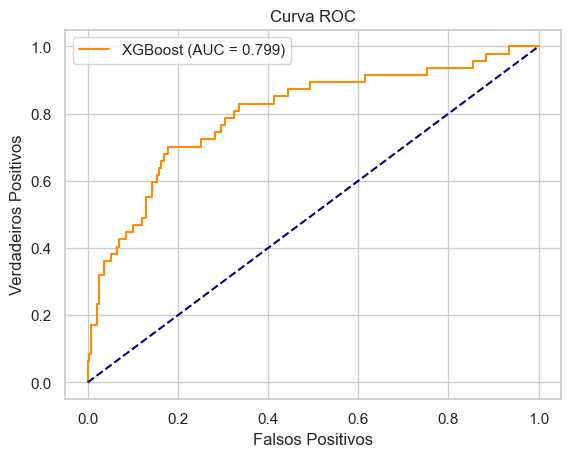

In [11]:
# Fator de Explicabilidade: Curva ROC
fpr, tpr, _ = roc_curve(y_test, probs)
plt.plot(fpr, tpr, color='darkorange', label=f'XGBoost (AUC = {roc_auc_score(y_test, probs):.3f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()